# Exploratory Data Analysis for Credit Risk

## Objective

This notebook investigates the relationships between borrower characteristics and serious delinquency risk.

## Key Questions

- Which borrowers have higher delinquency rates?
- How is age associated with credit risk?
- Do borrowers with missing income have different risk levels?
- How strongly does previous delinquency predict future delinquency?
- How are credit utilisation and debt ratio associated with risk?
- Which variables should be considered for modelling?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("/content/cs-training.csv")
df = df.rename(columns={"Unnamed: 0": "customer_id"})

target = "SeriousDlqin2yrs"

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150000, 12)


,customer_id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
def risk_table(data, group_column):
    result = (
        data.groupby(group_column, observed=False)[target]
        .agg(customer_count="count", default_rate="mean")
        .reset_index()
    )

    result["default_rate"] = (
        result["default_rate"] * 100
    ).round(2)

    return result

In [3]:
target_summary = df[target].value_counts().sort_index().reset_index()
target_summary.columns = ["target", "customer_count"]
target_summary["percentage"] = (
    target_summary["customer_count"] / len(df) * 100
).round(2)

target_summary

,target,customer_count,percentage
0,0,139974,93.32
1,1,10026,6.68


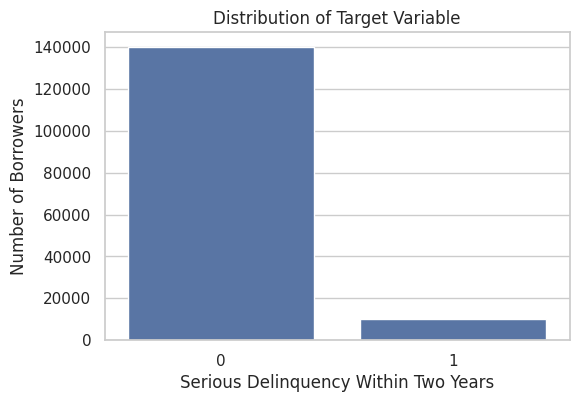

In [4]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=target)

plt.title("Distribution of Target Variable")
plt.xlabel("Serious Delinquency Within Two Years")
plt.ylabel("Number of Borrowers")
plt.show()

In [5]:
age_data = df[df["age"].between(18, 110)].copy()

age_data["age_group"] = pd.cut(
    age_data["age"],
    bins=[18, 30, 40, 50, 60, 70, np.inf],
    labels=["19–30", "31–40", "41–50", "51–60", "61–70", "71+"]
)

age_risk = risk_table(age_data, "age_group")
age_risk

,age_group,customer_count,default_rate
0,19–30,10757,11.56
1,31–40,24339,9.82
2,41–50,35037,8.26
3,51–60,34806,6.17
4,61–70,27424,3.47
5,71+,17636,2.26


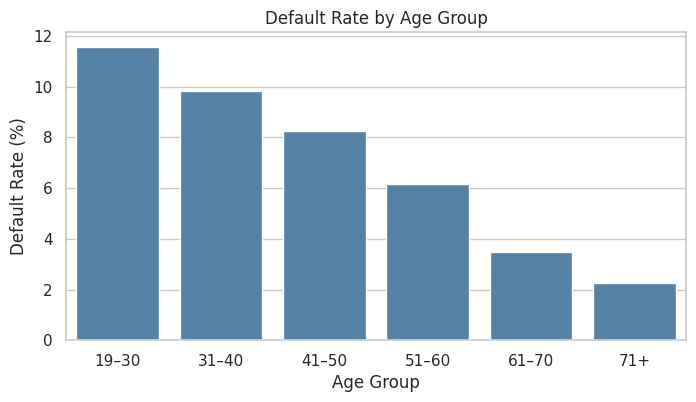

In [6]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=age_risk,
    x="age_group",
    y="default_rate",
    color="steelblue"
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.show()

In [7]:
df["income_status"] = np.where(
    df["MonthlyIncome"].isna(),
    "Missing",
    "Available"
)

income_missing_risk = risk_table(df, "income_status")
income_missing_risk

,income_status,customer_count,default_rate
0,Available,120269,6.95
1,Missing,29731,5.61


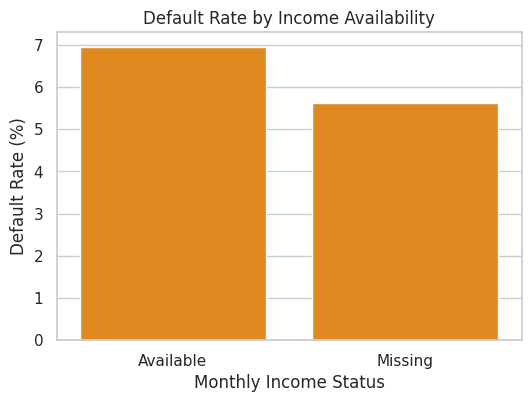

In [8]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=income_missing_risk,
    x="income_status",
    y="default_rate",
    color="darkorange"
)

plt.title("Default Rate by Income Availability")
plt.xlabel("Monthly Income Status")
plt.ylabel("Default Rate (%)")
plt.show()

In [9]:
income_data = df[
    df["MonthlyIncome"].notna() &
    (df["MonthlyIncome"] > 0)
].copy()

income_data["income_group"] = pd.qcut(
    income_data["MonthlyIncome"],
    q=10,
    labels=[
        "D1", "D2", "D3", "D4", "D5",
        "D6", "D7", "D8", "D9", "D10"
    ],
    duplicates="drop"
)

income_risk = risk_table(income_data, "income_group")
income_risk

,income_group,customer_count,default_rate
0,D1,12218,9.18
1,D2,11513,9.79
2,D3,12118,8.90
3,D4,11720,8.17
4,D5,11750,7.17
5,D6,12033,6.67
6,D7,11694,5.87
7,D8,12114,5.06
8,D9,11611,4.52
9,D10,11864,4.50


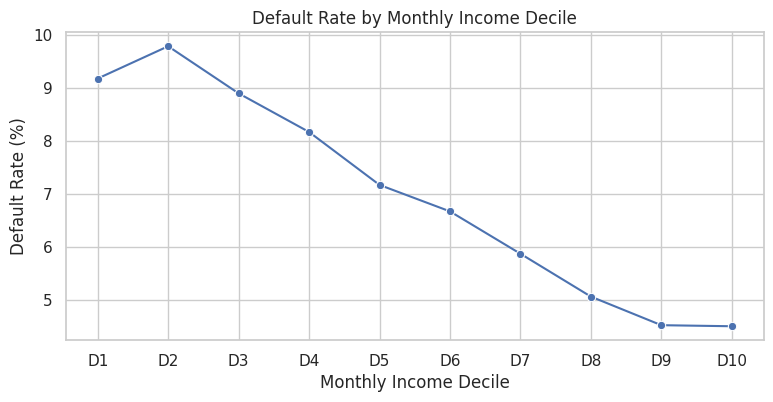

In [10]:
plt.figure(figsize=(9, 4))

sns.lineplot(
    data=income_risk,
    x="income_group",
    y="default_rate",
    marker="o"
)

plt.title("Default Rate by Monthly Income Decile")
plt.xlabel("Monthly Income Decile")
plt.ylabel("Default Rate (%)")
plt.show()

In [11]:
delinquency_data = df[
    ~df["NumberOfTimes90DaysLate"].isin([96, 98])
].copy()

delinquency_data["late_90_group"] = pd.cut(
    delinquency_data["NumberOfTimes90DaysLate"],
    bins=[-0.1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)

late_90_risk = risk_table(delinquency_data, "late_90_group")
late_90_risk

,late_90_group,customer_count,default_rate
0,0,141662,4.63
1,1,5243,33.66
2,2,1555,49.90
3,3+,1271,61.68


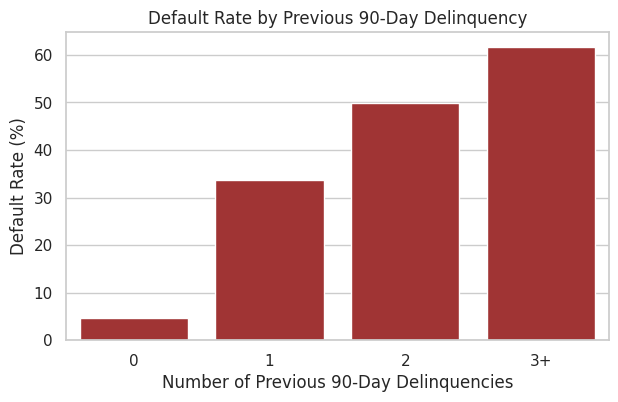

In [12]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=late_90_risk,
    x="late_90_group",
    y="default_rate",
    color="firebrick"
)

plt.title("Default Rate by Previous 90-Day Delinquency")
plt.xlabel("Number of Previous 90-Day Delinquencies")
plt.ylabel("Default Rate (%)")
plt.show()

In [13]:
utilisation_data = df[
    df["RevolvingUtilizationOfUnsecuredLines"].notna()
].copy()

utilisation_data["utilisation_group"] = pd.cut(
    utilisation_data["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-np.inf, 0, 0.25, 0.50, 0.75, 1, np.inf],
    labels=["0", "0–25%", "25–50%", "50–75%", "75–100%", "Above 100%"]
)

utilisation_risk = risk_table(
    utilisation_data,
    "utilisation_group"
)

utilisation_risk

,utilisation_group,customer_count,default_rate
0,0,10878,2.94
1,0–25%,76779,2.02
2,25–50%,21055,5.29
3,50–75%,13764,10.13
4,75–100%,24203,18.21
5,Above 100%,3321,37.25


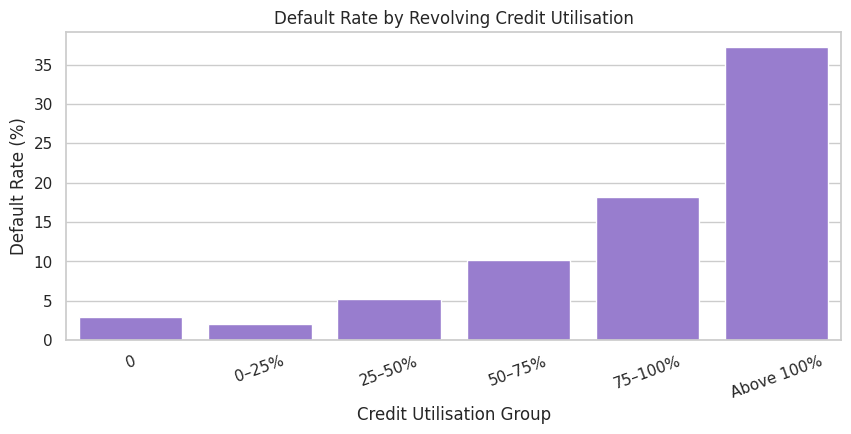

In [14]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=utilisation_risk,
    x="utilisation_group",
    y="default_rate",
    color="mediumpurple"
)

plt.title("Default Rate by Revolving Credit Utilisation")
plt.xlabel("Credit Utilisation Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [15]:
debt_data = df[
    df["MonthlyIncome"].notna() &
    df["DebtRatio"].notna()
].copy()

debt_data["debt_ratio_group"] = pd.cut(
    debt_data["DebtRatio"],
    bins=[-np.inf, 0.25, 0.50, 0.75, 1, 2, np.inf],
    labels=[
        "≤25%",
        "25–50%",
        "50–75%",
        "75–100%",
        "100–200%",
        "Above 200%"
    ]
)

debt_risk = risk_table(debt_data, "debt_ratio_group")
debt_risk

,debt_ratio_group,customer_count,default_rate
0,≤25%,50739,5.95
1,25–50%,41347,6.12
2,50–75%,15728,9.44
3,75–100%,5222,11.37
4,100–200%,3932,13.68
5,Above 200%,3301,5.91


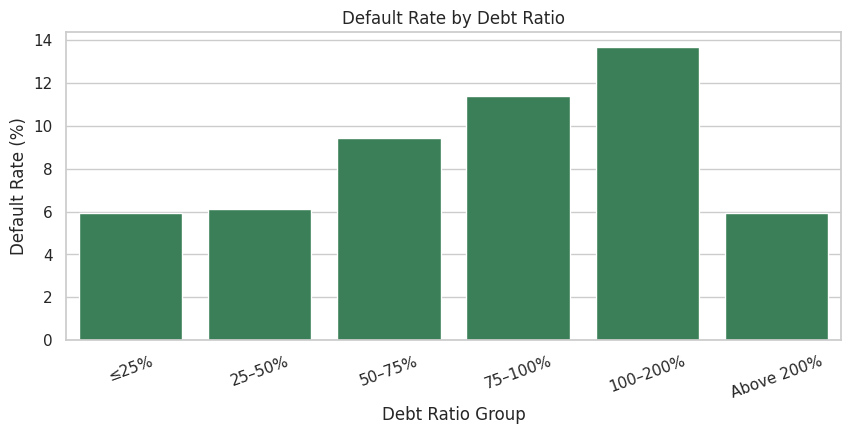

In [16]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=debt_risk,
    x="debt_ratio_group",
    y="default_rate",
    color="seagreen"
)

plt.title("Default Rate by Debt Ratio")
plt.xlabel("Debt Ratio Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [17]:
correlation_data = df.drop(
    columns=["customer_id", "income_status"]
).copy()

delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for column in delinquency_columns:
    correlation_data[column] = correlation_data[column].replace(
        [96, 98],
        np.nan
    )

correlation_matrix = correlation_data.corr(method="spearman")

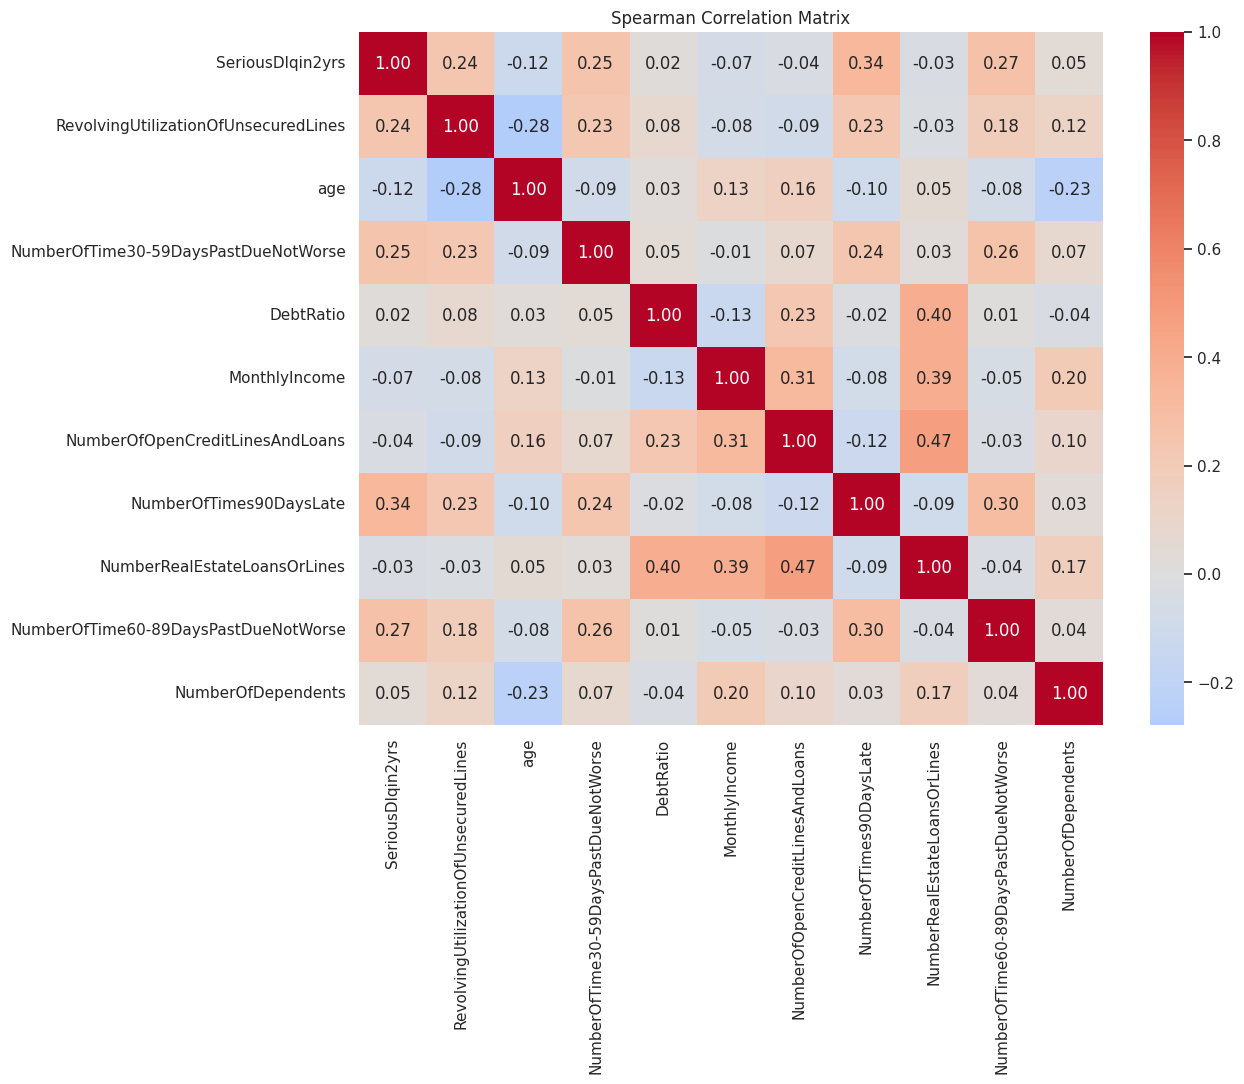

In [18]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Spearman Correlation Matrix")
plt.show()

## Key Findings

- The target variable is highly imbalanced, with approximately 6.68% positive cases.
- Age appears to be associated with delinquency risk, although the relationship should not be interpreted as causal.
- Missing monthly income may contain useful risk information and should be represented by a missing-value indicator.
- Previous delinquency history is expected to be one of the strongest predictors of future serious delinquency.
- Higher revolving credit utilisation is associated with higher risk.
- Debt ratio requires careful interpretation because extreme values and missing income may affect its meaning.
- The values 96 and 98 in delinquency variables should be treated as anomalous rather than ordinary delinquency counts.

## Candidate Features for Modelling

- Revolving credit utilisation
- Age
- Previous delinquency counts
- Debt ratio
- Monthly income
- Monthly income missing indicator
- Number of open credit lines and loans
- Number of real estate loans or lines
- Number of dependents

## Next Step

Develop a reproducible preprocessing strategy for missing values, anomalous values and numerical features.